In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/kaggle/input/weather-dataset/Project1WeatherDataset.csv')
df.head(10)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog
5,1/1/2012 5:00,-1.4,-3.3,87,9,6.4,101.27,Fog
6,1/1/2012 6:00,-1.5,-3.1,89,7,6.4,101.29,Fog
7,1/1/2012 7:00,-1.4,-3.6,85,7,8.0,101.26,Fog
8,1/1/2012 8:00,-1.4,-3.6,85,9,8.0,101.23,Fog
9,1/1/2012 9:00,-1.3,-3.1,88,15,4.0,101.20,Fog


In [3]:
df.index

RangeIndex(start=0, stop=8784, step=1)

In [4]:
df.columns

Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')

In [5]:
df.shape

(8784, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


In [7]:
df.describe()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,8.798144,2.555294,67.431694,14.945469,27.664447,101.051623
std,11.687883,10.883072,16.918881,8.688696,12.622688,0.844005
min,-23.300000,-28.500000,18.000000,0.000000,0.200000,97.520000
25%,0.100000,-5.900000,56.000000,9.000000,24.100000,100.560000
50%,9.300000,3.300000,68.000000,13.000000,25.000000,101.070000
75%,18.800000,11.800000,81.000000,20.000000,25.000000,101.590000
max,33.000000,24.400000,100.000000,83.000000,48.300000,103.650000


In [8]:
df.isna().sum() # no of nan/null values

Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

Date/Time            object
Temp_C              float64
Dew Point Temp_C    float64
Rel Hum_%             int64
Wind Speed_km/h       int64
Visibility_km       float64
Press_kPa           float64
Weather              object
dtype: object

In [11]:
df['Weather'].value_counts()

Weather
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Thunderstorms,Rain Showers                   16
Haze                                         16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                        11
Freezing Drizzle                

In [12]:
df['Weather'].nunique()

50

In [13]:
df.set_index('Date/Time', inplace=True)
df.sort_index(inplace=True)

In [14]:
X = df.drop(columns='Weather') 
y = df['Weather']

split_index = int(len(X) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [15]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(data=X_train, label=y_train)
test_pool = Pool(data=X_test, label=y_test)

model = CatBoostClassifier(
    loss_function='MultiClass',
    iterations=500,
    learning_rate=0.1,
    depth=5,
    eval_metric='Accuracy'
)

model.fit(train_pool, eval_set=test_pool, use_best_model=True)

0:	learn: 0.3354205	test: 0.3096187	best: 0.3096187 (0)	total: 132ms	remaining: 1m 5s
1:	learn: 0.3613206	test: 0.3147410	best: 0.3147410 (1)	total: 190ms	remaining: 47.3s
2:	learn: 0.3775438	test: 0.3261241	best: 0.3261241 (2)	total: 252ms	remaining: 41.7s
3:	learn: 0.3805322	test: 0.3619806	best: 0.3619806 (3)	total: 311ms	remaining: 38.5s
4:	learn: 0.3822399	test: 0.3671030	best: 0.3671030 (4)	total: 366ms	remaining: 36.3s
5:	learn: 0.3906361	test: 0.3847467	best: 0.3847467 (5)	total: 419ms	remaining: 34.5s
6:	learn: 0.3916323	test: 0.3762094	best: 0.3847467 (5)	total: 471ms	remaining: 33.1s
7:	learn: 0.3970400	test: 0.3790552	best: 0.3847467 (5)	total: 518ms	remaining: 31.8s
8:	learn: 0.4054362	test: 0.3875925	best: 0.3875925 (8)	total: 569ms	remaining: 31.1s
9:	learn: 0.4078554	test: 0.3910074	best: 0.3910074 (9)	total: 618ms	remaining: 30.3s
10:	learn: 0.4082823	test: 0.3978372	best: 0.3978372 (10)	total: 670ms	remaining: 29.8s
11:	learn: 0.4088516	test: 0.3978372	best: 0.3978372

In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (weighted):", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall (weighted):", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1 Score (weighted):", f1_score(y_test, y_pred, average='weighted', zero_division=0))

Accuracy: 0.4063745019920319
Precision (weighted): 0.4050976530548236
Recall (weighted): 0.4063745019920319
F1 Score (weighted): 0.39900106575465916


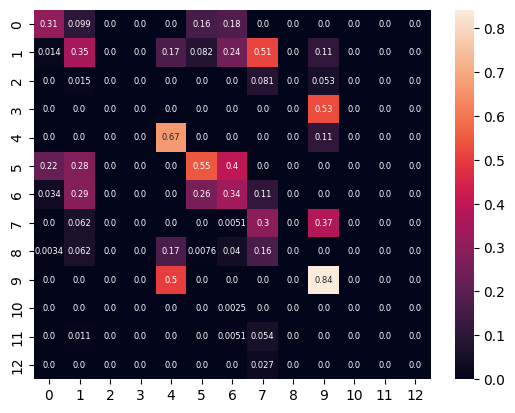

In [17]:
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cfm = confusion_matrix(y_test, y_pred)

sb.heatmap(cfm / np.sum(cfm, axis=1), annot=True, fmt=".2", annot_kws={"size": 6})
plt.show()

In [18]:
model.save_model("catboost_model.cbm")